# 73 — GradCAM Analysis (arahan dosen #1)

**Tujuan:** Visualisasi bobot NN — model fokus ke bagian citra apa (mata, mulut, alis, dahi)? GradCAM (Selvaraju et al., 2017) menghasilkan heatmap yang menunjukkan region gambar yang paling berpengaruh terhadap prediksi kelas tertentu.

**Target model (dari best val-tuned Primer conf60):**
- **CNN TL 4c B1** (single-modal baseline, Macro F1 = 0.456)
- **Intermediate TL 4c B3** image branch (best overall, Macro F1 = 0.521)

**Output:**
- `docs/figures/gradcam/*.png` — overlay grid per model, 2 sampel per kelas
- Kualitatif: bandingkan apakah fusion bergeser fokus dibanding single-modal

**Setup (di VPS):**
```bash
pip install grad-cam
```


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import torch
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from training.models import EmotionCNNTransfer, IntermediateFusionTransfer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

DATA_DIR = PROJECT_ROOT / 'data' / 'dataset_frontonly_conf60'
CKPT_DIR = PROJECT_ROOT / 'models' / 'frontonly_conf60'
OUT_DIR  = PROJECT_ROOT / 'docs' / 'figures' / 'gradcam'
OUT_DIR.mkdir(parents=True, exist_ok=True)

EMOTIONS_4 = ['neutral', 'happy', 'sad', 'negative']
REMAP_4 = np.array([0, 1, 2, 3, 3, 3, 3], dtype=np.int64)

Device: cuda


In [2]:
# ── Load test data + pick 2 representative samples per class ──
t_img = np.load(DATA_DIR / 'X_test_images.npy')
t_lm  = np.load(DATA_DIR / 'X_test_landmarks.npy')
t_y7  = np.load(DATA_DIR / 'y_test.npy')
t_y4  = REMAP_4[t_y7]

rng = np.random.RandomState(42)
sample_idx = []
for cls in range(4):
    pool = np.where(t_y4 == cls)[0]
    if len(pool) >= 2:
        sample_idx.extend(rng.choice(pool, size=2, replace=False).tolist())
    else:
        sample_idx.extend(pool.tolist())
print(f'Selected {len(sample_idx)} sample indices: {sample_idx}')
print(f'Class distribution: {[EMOTIONS_4[int(t_y4[i])] for i in sample_idx]}')

Selected 8 sample indices: [432, 890, 355, 454, 662, 664, 289, 894]
Class distribution: ['neutral', 'neutral', 'happy', 'happy', 'sad', 'sad', 'negative', 'negative']


In [3]:
# ── Helper: run GradCAM on one model + save overlay grid ──
def run_gradcam(model, target_layer, name, uses_landmark=False):
    """Save grid of GradCAM overlays (2 rows × 4 cols = 8 samples, 2 per class)."""
    model.eval()
    cam = GradCAM(model=model, target_layers=[target_layer])

    fig, axes = plt.subplots(2, 4, figsize=(14, 7.2))
    for ax, idx in zip(axes.ravel(), sample_idx):
        img01 = np.clip(t_img[idx], 0, 1).astype(np.float32)
        img_t = torch.from_numpy(img01).permute(2, 0, 1).unsqueeze(0).to(device)
        target = [ClassifierOutputTarget(int(t_y4[idx]))]

        if uses_landmark:
            lm_t = torch.from_numpy(t_lm[idx]).float().unsqueeze(0).to(device)
            orig_fwd = model.forward
            model.forward = lambda x, _lm=lm_t: orig_fwd(x, _lm)
            try:
                grayscale_cam = cam(input_tensor=img_t, targets=target)[0]
            finally:
                model.forward = orig_fwd
        else:
            grayscale_cam = cam(input_tensor=img_t, targets=target)[0]

        overlay = show_cam_on_image(img01, grayscale_cam, use_rgb=True)
        ax.imshow(overlay)
        ax.set_title(f'{EMOTIONS_4[int(t_y4[idx])]}  (idx {idx})', fontsize=9)
        ax.axis('off')

    plt.suptitle(f'GradCAM — {name}', fontsize=11)
    plt.tight_layout()
    out = OUT_DIR / f'{name}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

Ckpt 1: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class_tl/cnn_tl_b1.pth  exists=True


Target layer: BasicBlock


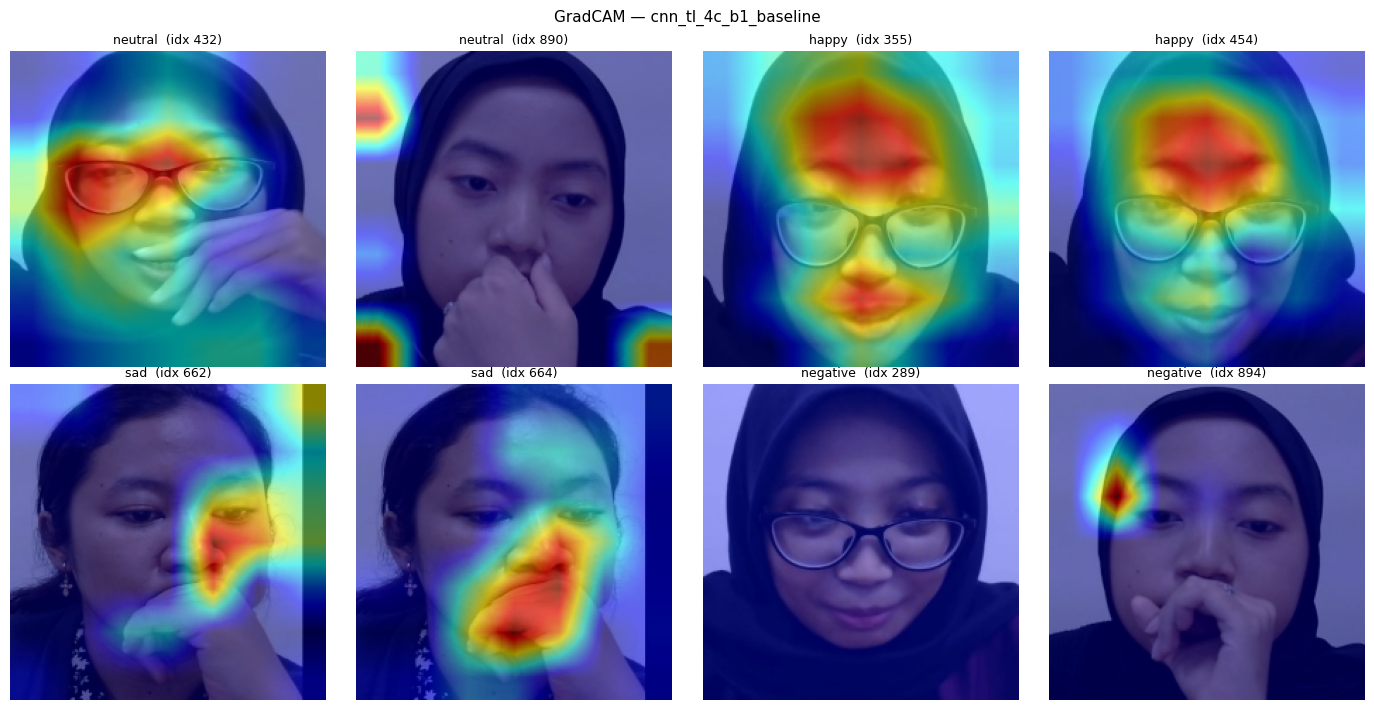

Saved: /home/bs000716/MOTHER-TANK/TRAIN/docs/figures/gradcam/cnn_tl_4c_b1_baseline.png


In [4]:
# ── Model 1: CNN TL 4c B1 (single-modal baseline) ──
ckpt1 = CKPT_DIR / '4class_tl' / 'cnn_tl_b1.pth'
print(f'Ckpt 1: {ckpt1}  exists={ckpt1.exists()}')

if ckpt1.exists():
    m1 = EmotionCNNTransfer(num_classes=4).to(device)
    m1.load_state_dict(torch.load(ckpt1, map_location=device, weights_only=True))

    # ResNet18 last conv block: model.features is nn.Sequential; last conv block is at [-2]
    # (features[-1] is avg pool, features[-2] is last BasicBlock layer)
    target_layer = m1.features[-2][-1]
    print(f'Target layer: {type(target_layer).__name__}')

    run_gradcam(m1, target_layer, 'cnn_tl_4c_b1_baseline')
else:
    print(f'[SKIP] checkpoint not found — adjust path sesuai naming di VPS')

Ckpt 2: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class_tl/intermediate_tl_b3.pth  exists=True


IntermediateFusionTransfer sub-modules:
  image_features
  image_fc
  landmark_features
  fusion_head
Target layer: BasicBlock


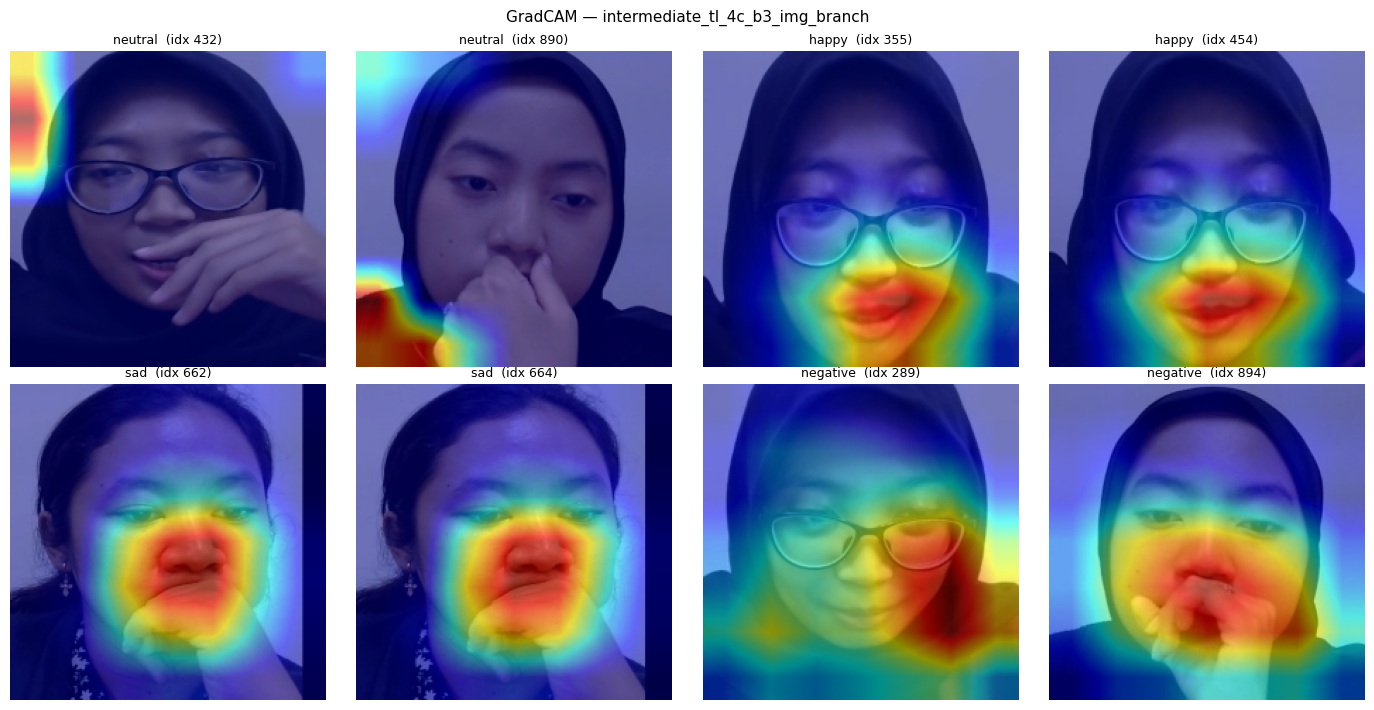

Saved: /home/bs000716/MOTHER-TANK/TRAIN/docs/figures/gradcam/intermediate_tl_4c_b3_img_branch.png


In [5]:
# ── Model 2: Intermediate TL 4c B3 — image branch (best overall, val-tuned) ──
ckpt2 = CKPT_DIR / '4class_tl' / 'intermediate_tl_b3.pth'
print(f'Ckpt 2: {ckpt2}  exists={ckpt2.exists()}')

if ckpt2.exists():
    m2 = IntermediateFusionTransfer(num_classes=4).to(device)
    m2.load_state_dict(torch.load(ckpt2, map_location=device, weights_only=True))

    # Inspect model structure to pick correct layer
    print('IntermediateFusionTransfer sub-modules:')
    for n, _ in m2.named_children():
        print(f'  {n}')

    # Common naming: image_features / cnn / resnet; adjust if needed after inspect above
    img_branch = getattr(m2, 'image_features', None) or getattr(m2, 'cnn', None)
    if img_branch is None:
        raise AttributeError('Adjust attribute name for image branch (see printed sub-modules)')
    target_layer2 = list(img_branch.children())[-2][-1]
    print(f'Target layer: {type(target_layer2).__name__}')

    run_gradcam(m2, target_layer2, 'intermediate_tl_4c_b3_img_branch',
                uses_landmark=True)
else:
    print(f'[SKIP] checkpoint not found')

## Qualitative Analysis (setelah overlay dihasilkan)

Inspect PNG di `docs/figures/gradcam/` per kelas:

| Class | Expected focus |
|-------|---------------|
| neutral | eyes / mouth region (netral, tidak distinct) |
| happy | mouth (smile) + eye crinkle |
| sad | brow + mouth corners (downturn) |
| negative | variabel (heterogen: angry/fearful/disgusted/surprised di merge) |

**Bandingkan CNN TL baseline vs Intermediate TL image branch:** apakah fusion dengan landmark stream menggeser fokus ke region yang berbeda? (hipotesis: Intermediate fusion mungkin kurang fokus ke mata karena info geometri sudah di-cover landmark stream).

**Output PNG** bisa langsung dimasukkan ke BAB Discussion tesis sebagai Fig. X GradCAM qualitative analysis.